# Loading model

In [ ]:
!git clone https://github.com/DepthAnything/Depth-Anything-V2
%cd Depth-Anything-V2
!pip install -r requirements.txt

fatal: destination path 'Depth-Anything-V2' already exists and is not an empty directory.
/content/Depth-Anything-V2


In [ ]:
!wget -P /content https://huggingface.co/depth-anything/Depth-Anything-V2-Large/resolve/main/depth_anything_v2_vitl.pth?download=true

--2025-05-26 21:34:02--  https://huggingface.co/depth-anything/Depth-Anything-V2-Large/resolve/main/depth_anything_v2_vitl.pth?download=true
Resolving huggingface.co (huggingface.co)... 3.166.152.65, 3.166.152.105, 3.166.152.110, ...
Connecting to huggingface.co (huggingface.co)|3.166.152.65|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://cdn-lfs-us-1.hf.co/repos/ef/a0/efa040f8dfeabb0d7e03dde47070ea9d72db9ffe066eb5d6a44a7a2803a1477c/a7ea19fa0ed99244e67b624c72b8580b7e9553043245905be58796a608eb9345?response-content-disposition=attachment%3B+filename*%3DUTF-8%27%27depth_anything_v2_vitl.pth%3B+filename%3D%22depth_anything_v2_vitl.pth%22%3B&Expires=1748298842&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTc0ODI5ODg0Mn19LCJSZXNvdXJjZSI6Imh0dHBzOi8vY2RuLWxmcy11cy0xLmhmLmNvL3JlcG9zL2VmL2EwL2VmYTA0MGY4ZGZlYWJiMGQ3ZTAzZGRlNDcwNzBlYTlkNzJkYjlmZmUwNjZlYjVkNmE0NGE3YTI4MDNhMTQ3N2MvYTdlYTE5ZmEwZWQ5OTI0NGU2N2I2MjRjNzJiOD

In [ ]:
import cv2
import torch

from depth_anything_v2.dpt import DepthAnythingV2

DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

model = DepthAnythingV2(encoder='vitl', features=256, out_channels=[256, 512, 1024, 1024])
model.load_state_dict(torch.load('/content/depth_anything_v2_vitl.pth?download=true', map_location='cpu'))
model = model.to(DEVICE).eval()

#raw_img = cv2.imread('/content/istockphoto-1411322814-612x612.jpg')
#depth = model.infer_image(raw_img) # HxW raw depth map in numpy

In [ ]:
from google.colab.patches import cv2_imshow

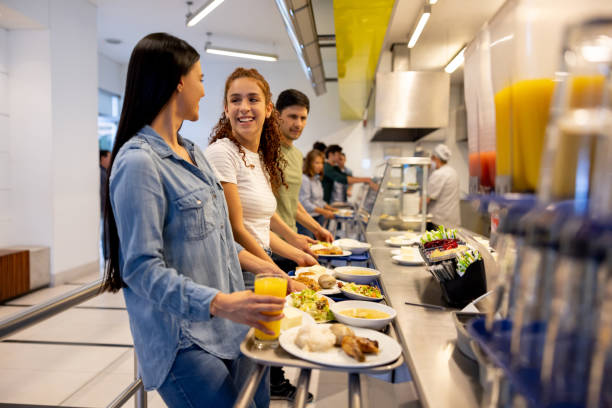

In [ ]:
cv2_imshow(raw_img)

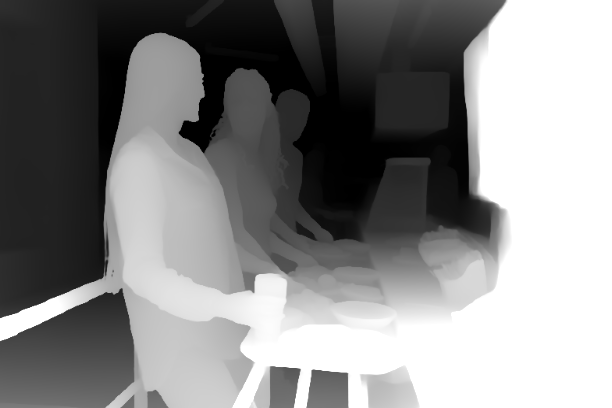

In [ ]:
cv2_imshow(depth)

# Video to Frames and Frames to Video

In [ ]:
frames = read_video_frames('/content/0000f77c-6257be58.mp4', skip=5)

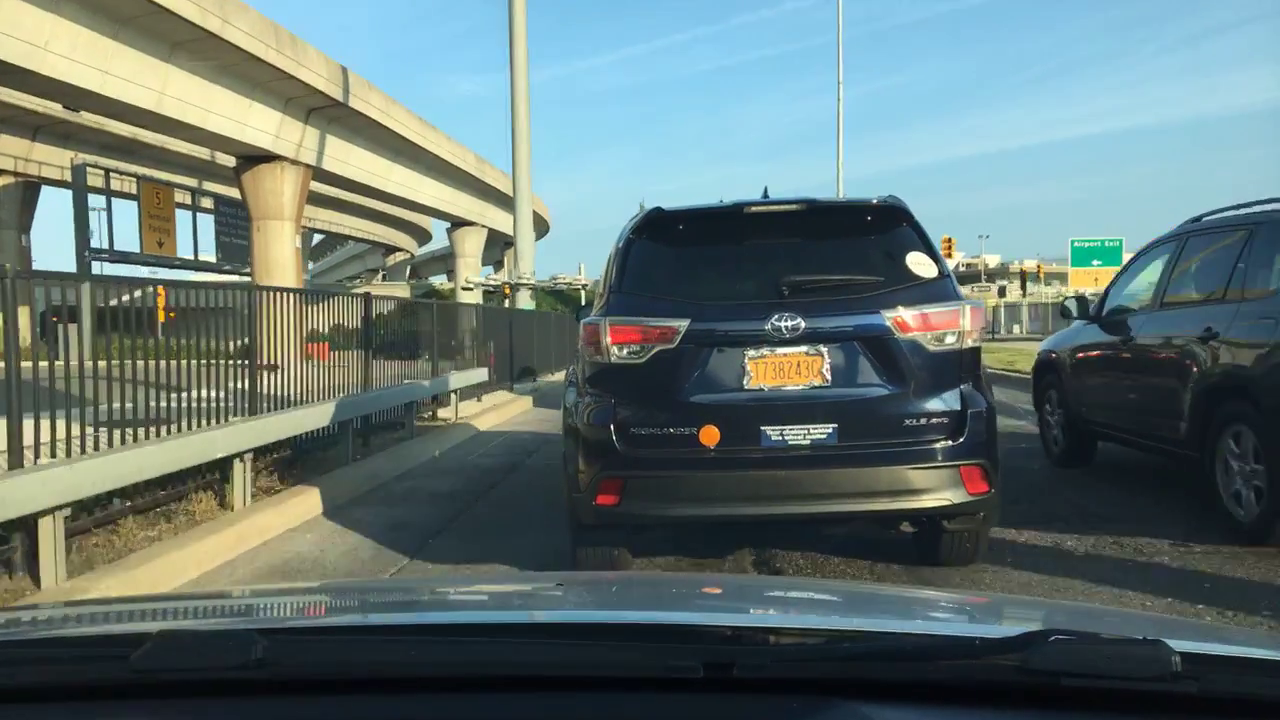

In [ ]:
cv2_imshow(frames[2])

In [ ]:
create_video_from_frames(frames, '/content/0000f77c-6257be58.mp4')

NameError: name 'create_video_from_frames' is not defined

In [ ]:
from tqdm import tqdm

depths = []

for i in tqdm(frames, desc="Processing frames", unit="frame"):
    depth = model.infer_image(i)
    depths.append(depth)

Processing frames: 100%|██████████| 111/111 [01:38<00:00,  1.12frame/s]


In [ ]:
# Assuming 'frames' is a list of RGB images and 'model' is your initialized Depth-Anything-V2 model
raw_depths, color_depths = generate_depth_and_colormap_frames(frames, model)

Processing frames:   0%|          | 0/42 [01:05<?, ?frame/s]


KeyboardInterrupt: 

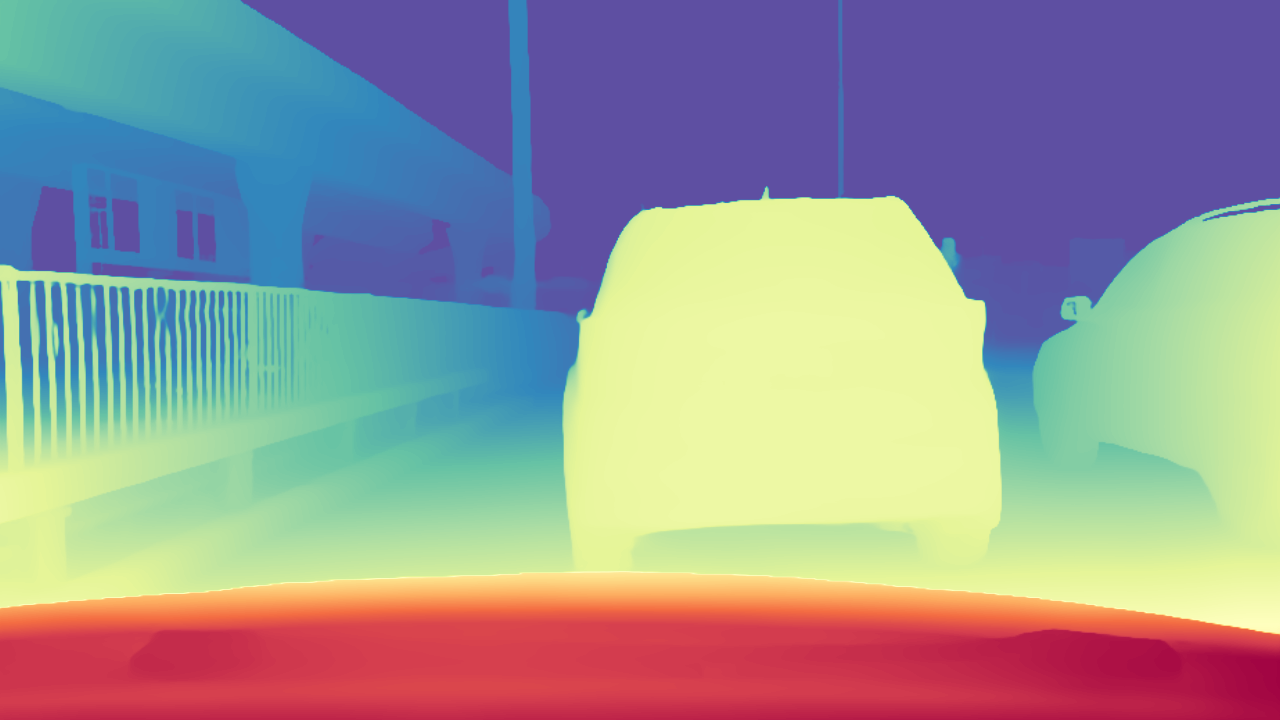

In [ ]:
cv2_imshow(color_depths[2])

In [ ]:
create_video_from_frames(frames, '/content/output_original.mp4')

Video saved to /content/output_original.mp4


In [ ]:
create_video_from_frames(raw_depths, '/content/output_depth.mp4')

Video saved to /content/output_depth.mp4


In [ ]:
create_video_from_frames(color_depths, '/content/output_color.mp4')

Video saved to /content/output_color.mp4


# Wordpress Integration

In [ ]:
from datetime import datetime

In [ ]:
website = "https://dev-gvi-mapper.pantheonsite.io"
username = "Abdus Sami"
password = "wgan J1d6 BIQL Om3Q j3If 5foZ"

## Send Video file

In [ ]:
import requests
from requests.auth import HTTPBasicAuth

# File to upload
video_path = "/content/output_color (1).mp4"

# WordPress API URL (update with your domain)
wp_url = "https://dev-gvi-mapper.pantheonsite.io/wp-json/wp/v2/media"

# WordPress credentials
username = "Abdus Sami"
app_password = "wgan J1d6 BIQL Om3Q j3If 5foZ"  # Only the password part, not 'username:password'

# Read video file
with open(video_path, 'rb') as f:
    video_data = f.read()

# Prepare headers
headers = {
    'Content-Disposition': f'attachment; filename="{video_path}"',
    'Content-Type': 'video/mp4',
}

# Send POST request
response = requests.post(
    wp_url,
    headers=headers,
    data=video_data,
    auth=HTTPBasicAuth(username, app_password)
)

# Result
if response.status_code == 201:
    print("✅ Uploaded successfully!")
    print("📹 Video URL:", response.json()['source_url'])
else:
    print("❌ Upload failed:", response.status_code)
    print(response.text)

✅ Uploaded successfully!
📹 Video URL: https://dev-gvi-mapper.pantheonsite.io/wp-content/uploads/2025/05/contentoutput_color-1.mp4


## Receive Video

In [ ]:
from datetime import datetime

now = datetime.now()
current_year = now.year
current_month = now.month

print(f"Year: {current_year}, Month: {current_month}")


Year: 2025, Month: 5


In [ ]:
import requests

video_url = 'https://dev-gvi-mapper.pantheonsite.io/wp-content/uploads/2025/05/3209828-uhd_3840_2160_25fps.mp4'
local_filename = 'sample-video.mp4'

with requests.get(video_url, stream=True) as r:
    r.raise_for_status()
    with open(local_filename, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)

print(f"Downloaded video to {local_filename}")

Downloaded video to sample-video.mp4


# Prepare

In [ ]:
!git clone https://github.com/DepthAnything/Depth-Anything-V2
%cd Depth-Anything-V2
!pip install -r requirements.txt

In [ ]:
!wget -P /content https://huggingface.co/depth-anything/Depth-Anything-V2-Large/resolve/main/depth_anything_v2_vitl.pth?download=true

# FYP code full form

In [ ]:
import requests
from datetime import datetime
from requests.auth import HTTPBasicAuth
import os
import cv2
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from depth_anything_v2.dpt import DepthAnythingV2

## Functions

In [ ]:
def download_video(website_url: str, filename: str):
    now = datetime.now()
    year = str(now.year)
    month = f"{now.month:02d}"  # Zero-padded month

    # Construct full video URL
    url = f"{website_url}/wp-content/uploads/{year}/{month}/{filename}"

    try:
        with requests.get(url, stream=True) as r:
            r.raise_for_status()
            with open('data.mp4', 'wb') as f:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)
        print(f"Downloaded video to {'data.mp4'}")
    except Exception as e:
        print(f"Failed to download video: {e}")

In [ ]:
def read_video_frames(video_path, skip=0):

    frames = []
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print(f"Error: Cannot open video file {video_path}")
        return frames

    frame_index = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break  # End of video

        if frame_index % (skip + 1) == 0:
            frames.append(frame)

        frame_index += 1

    cap.release()
    return frames


In [ ]:
def generate_depth_and_colormap_frames(frames, model, input_size=518, colormap_name='Spectral_r'):
    raw_depths = []
    color_depths = []

    # Retrieve the specified colormap
    cmap = plt.get_cmap(colormap_name)

    for frame in tqdm(frames, desc="Processing frames", unit="frame"):
        # Ensure the frame is in RGB format
        if frame.shape[2] == 3:
            rgb_frame = frame
        else:
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Obtain the depth map from the model
        depth = model.infer_image(rgb_frame, input_size)

        # Normalize the depth map to 0-255
        depth_min = depth.min()
        depth_max = depth.max()
        if depth_max - depth_min > 0:
            depth_normalized = (depth - depth_min) / (depth_max - depth_min)
        else:
            depth_normalized = np.zeros_like(depth)

        depth_8bit = (depth_normalized * 255).astype(np.uint8)

        # Store the raw depth map
        raw_depths.append(depth_8bit)

        # Apply the colormap
        depth_colored = cmap(depth_8bit)
        depth_colored = (depth_colored[:, :, :3] * 255).astype(np.uint8)

        # Convert RGB to BGR for OpenCV compatibility
        depth_colored_bgr = cv2.cvtColor(depth_colored, cv2.COLOR_RGB2BGR)

        # Store the color-mapped depth image
        color_depths.append(depth_colored_bgr)

    return raw_depths, color_depths


In [ ]:
def create_video_from_frames(frames, output_path, fps=30):
    if not frames:
        print("Error: No frames provided.")
        return

    # Get frame shape and determine color format
    first_frame = frames[0]
    if len(first_frame.shape) == 2:  # grayscale
        height, width = first_frame.shape
        is_color = False
    elif len(first_frame.shape) == 3 and first_frame.shape[2] == 3:  # color
        height, width, _ = first_frame.shape
        is_color = True
    else:
        print("Error: Unsupported frame format.")
        return

    # Choose codec
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height), isColor=is_color)

    for idx, frame in enumerate(frames):
        # Resize check
        if frame.shape[:2] != (height, width):
            print(f"Error: Frame {idx} has mismatched dimensions.")
            out.release()
            return

        # Normalize and convert to uint8 if needed
        if frame.dtype != np.uint8:
            frame = cv2.normalize(frame, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

        # Convert grayscale to BGR only if writing color video
        if is_color and len(frame.shape) == 2:
            frame = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)

        # Convert color to grayscale if needed (very rare)
        if not is_color and len(frame.shape) == 3:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        out.write(frame)

    out.release()
    print(f"✅ Video saved to {output_path}")

In [ ]:
def upload_video_to_wordpress(
    video_path: str,
    wp_url: str,
    username: str,
    app_password: str
):
    try:
        filename = os.path.basename(video_path)
        with open(video_path, 'rb') as f:
            files = {'file': (filename, f, 'video/mp4')}

            response = requests.post(
                wp_url,
                files=files,
                auth=HTTPBasicAuth(username, app_password),
                timeout=30
            )

        if response.status_code == 201:
            try:
                video_url = response.json().get('source_url')
                if video_url:
                    print("✅ Uploaded successfully!")
                    print("📹 Video URL:", video_url)
                    return video_url
                else:
                    print("❌ Upload succeeded but 'source_url' not found in response.")
                    return None
            except Exception as e:
                print(f"⚠️ Failed to parse response JSON: {e}")
                return None
        else:
            print(f"❌ Upload failed with status {response.status_code}")
            print(response.text)
            return None

    except Exception as e:
        print(f"⚠️ Exception occurred: {e}")
        return None

## Code

In [ ]:
download_video(website,'input_data.mp4')
frames = read_video_frames('/content/data.mp4', skip=5)


DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
model = DepthAnythingV2(encoder='vitl', features=256, out_channels=[256, 512, 1024, 1024])
model.load_state_dict(torch.load('/content/depth_anything_v2_vitl.pth?download=true', map_location='cpu'))
model = model.to(DEVICE).eval()


raw_depths, color_depths = generate_depth_and_colormap_frames(frames, model)

create_video_from_frames(frames, '/content/output_original.mp4')
create_video_from_frames(raw_depths, '/content/output_depths.mp4')
create_video_from_frames(frames, '/content/output_color.mp4')

upload_video_to_wordpress('/content/output_original.mp4','https://dev-gvi-mapper.pantheonsite.io/wp-json/wp/v2/media','Abdus Sami','wgan J1d6 BIQL Om3Q j3If 5foZ')
upload_video_to_wordpress('/content/output_depths.mp4','https://dev-gvi-mapper.pantheonsite.io/wp-json/wp/v2/media','Abdus Sami','wgan J1d6 BIQL Om3Q j3If 5foZ')
upload_video_to_wordpress('/content/output_color.mp4','https://dev-gvi-mapper.pantheonsite.io/wp-json/wp/v2/media','Abdus Sami','wgan J1d6 BIQL Om3Q j3If 5foZ')